In [1]:
%load_ext autoreload
%autoreload 2

Text(0, 0.5, 'count')

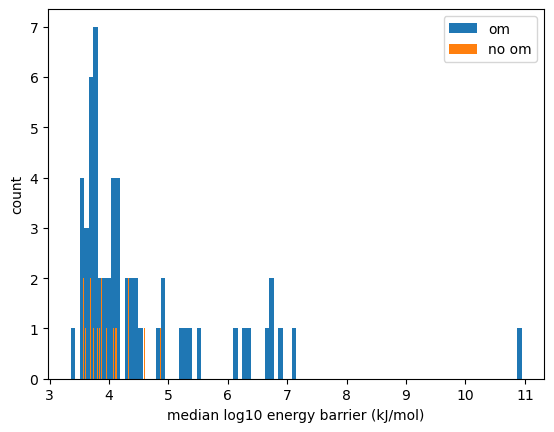

In [4]:
import torch
import numpy as np
from openmm.app import *
from openmm import *
from openmm.unit import *
import matplotlib.pyplot as plt
from pdbfixer import PDBFixer
import io
from io import StringIO
import mdtraj as md
from tqdm import tqdm
import os

# Compute energy barriers for all tetrapeptides
exp_name = "main_eval_output_om_interpolate_test_april8_model_fulldataset_dt=0.0002_flowmatching"
path = "saved_models/tetrapeptides_all_atom/" + exp_name
energies  = []
for file in os.listdir(path):
    if file.endswith(".pt") and "energies" in file:
        file_name = os.path.join(path, file)
        en = torch.load(file_name)
        energies.append(en.max(1)[0].cpu().log10().mean())

out = plt.hist(energies, bins=100, label="om")

exp_name = "main_eval_output_interpolate_test_latent_time=7_flowmatching"
path = "saved_models/tetrapeptides_all_atom/" + exp_name
energies  = []
for file in os.listdir(path):
    if file.endswith(".pt") and "energies" in file:
        file_name = os.path.join(path, file)
        en = torch.load(file_name)
        energies.append(en.max(1)[0].cpu().log10().median())

out = plt.hist(energies, bins=100, label="no om")
plt.legend()
plt.xlabel("median log10 energy barrier (kJ/mol)")
plt.ylabel("count")




        

  


In [17]:
in_path = "saved_models/tetrapeptides_all_atom/main_eval_output_om_interpolate_test_april8_model_fulldataset_dt=0.0002_flowmatching/AVGR_0.pdb"
out_path = "test.pdb"
fix_pdb_file(in_path, out_path)

 11%|█         | 11/100 [00:30<04:07,  2.78s/it]


11it [00:25,  2.36s/it]


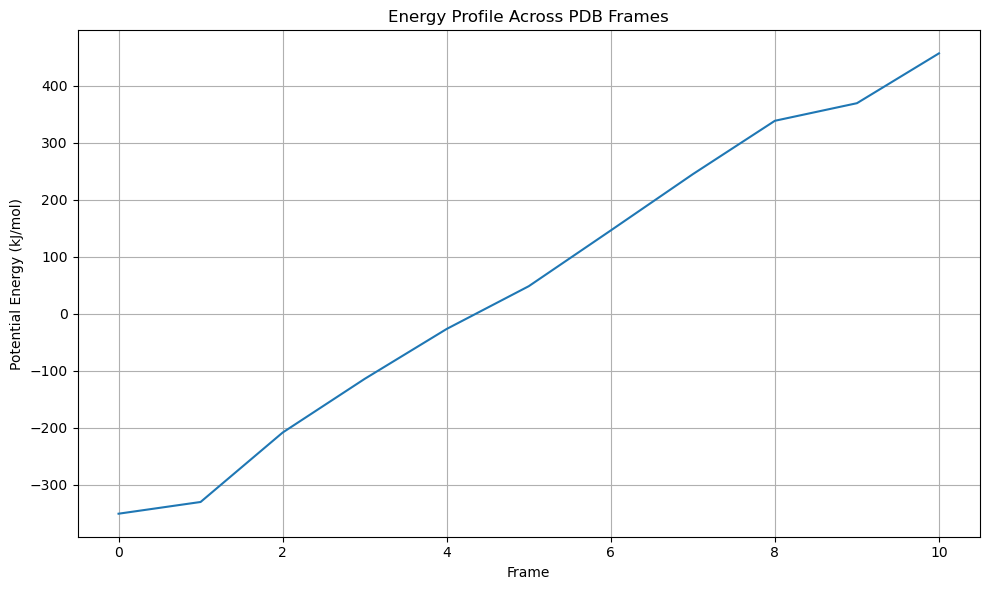

In [21]:
energies = compute_energies(out_path)


In [4]:
file = PDBFile("saved_models/tetrapeptides_all_atom/main_eval_output_om_interpolate_test_april8_model_fulldataset_dt=0.0002_flowmatching/AVGR_0.pdb")

ValueError: invalid literal for int() with base 10: ''

In [9]:
import mdtraj as md
# traj = md.load("saved_models/tetrapeptides_all_atom/main_eval_output_om_interpolate_test_april8_model_fulldataset_dt=0.0002_flowmatching/AVGR_0.xtc", top = "/data/sanjeevr/4AA_sim/AVGR/AVGR.pdb")

top = md.load("/home/sanjeevr/om-diffusion/two-for-one-diffusion/saved_models/tetrapeptides_all_atom/main_eval_output_om_interpolate_test_april8_model_fulldataset_dt=0.0002_flowmatching/AVGR_0.pdb")
top.save_pdb("test.pdb")
file = PDBFile("test.pdb")